In [10]:
import pandas as pd
import ast
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
import torch
import evaluate
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings("ignore")

In [11]:
df = pd.read_csv('rnc_dataset.csv')
df['targetDetectedMcIds'] = df['targetDetectedMcIds'].apply(ast.literal_eval)
df['targetSplitMcIds'] = df['targetSplitMcIds'].apply(ast.literal_eval)

# 1. Проверка уникальных категорий и их частоты
all_labels = sorted(set([label for labels in df['targetDetectedMcIds'] for label in labels]))
print(f"Всего категорий: {len(all_labels)}")

# 2. Разделение данных по столбцу split
train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'val']
test_df = df[df['split'] == 'test']

print(train_df)
print(val_df)
print(test_df)

Всего категорий: 11
      itemId  sourceMcId                    sourceMcTitle  \
0          1         108               Штукатурные работы   
3          4         102                       Сантехника   
4          5         101  Ремонт квартир и домов под ключ   
5          6         106                   Поклейка обоев   
6          7         109               Напольные покрытия   
...      ...         ...                              ...   
2993    2994         101  Ремонт квартир и домов под ключ   
2994    2995         106                   Поклейка обоев   
2996    2997         101  Ремонт квартир и домов под ключ   
2997    2998         111               Демонтажные работы   
2998    2999         101  Ремонт квартир и домов под ключ   

                                            description  \
0     штукатурка под обои в офис. Делаю ремонт штука...   
3     Монтаж сантехники в коттедж. Делаю монтаж бойл...   
4     Комплекс работ по ремонту во вторичке. гкл, гк...   
5     Оклей

In [12]:
# ====================== 1. Подготовка меток ======================
all_mc_ids = sorted(set([mc for mcs in df['targetDetectedMcIds'] for mc in mcs]))
id2idx = {mc_id: i for i, mc_id in enumerate(all_mc_ids)}
print(f"Всего микрокатегорий: {len(all_mc_ids)}")

def create_multi_label_matrix(df: pd.DataFrame, target_column: str):
    matrix = np.zeros((len(df), len(all_mc_ids)), dtype=np.float32)
    for idx, mc_list in enumerate(df[target_column]):
        for mc in mc_list:
            if mc in id2idx:
                matrix[idx, id2idx[mc]] = 1.0
    return matrix

train_detected = create_multi_label_matrix(train_df, 'targetDetectedMcIds')
train_split    = create_multi_label_matrix(train_df, 'targetSplitMcIds')
val_detected   = create_multi_label_matrix(val_df,   'targetDetectedMcIds')
val_split      = create_multi_label_matrix(val_df,   'targetSplitMcIds')

# ====================== 2. Подготовка текста ======================
def prepare_text(row):
    return f"Исходная категория: {row['sourceMcTitle']} (ID {row['sourceMcId']}). {row['description']}"

train_df['text'] = train_df.apply(prepare_text, axis=1)
val_df['text']   = val_df.apply(prepare_text, axis=1)

# ====================== 3. Токенизация ======================
tokenizer = AutoTokenizer.from_pretrained("deepvk/USER2-base")   # ты выбрал этот

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

# Detected
train_dataset_d = Dataset.from_pandas(train_df[['text']]).map(tokenize_function, batched=True)
train_dataset_d = train_dataset_d.add_column("labels", train_detected.tolist())

val_dataset_d = Dataset.from_pandas(val_df[['text']]).map(tokenize_function, batched=True)
val_dataset_d = val_dataset_d.add_column("labels", val_detected.tolist())

# Split
train_dataset_s = Dataset.from_pandas(train_df[['text']]).map(tokenize_function, batched=True)
train_dataset_s = train_dataset_s.add_column("labels", train_split.tolist())

val_dataset_s = Dataset.from_pandas(val_df[['text']]).map(tokenize_function, batched=True)
val_dataset_s = val_dataset_s.add_column("labels", val_split.tolist())

# ====================== 4. Тренер с улучшенными параметрами ======================
def get_trainer(train_ds, val_ds, output_dir):
    model = AutoModelForSequenceClassification.from_pretrained(
        "deepvk/USER2-base",                    # лучше взять ту же базу, что и токенизатор
        num_labels=len(all_mc_ids),
        problem_type="multi_label_classification"
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = (torch.sigmoid(torch.tensor(logits)) > 0.5).numpy().astype(int)
        
        f1 = evaluate.load("f1").compute(predictions=preds.flatten(), 
                                        references=labels.flatten(), average="micro")
        precision = evaluate.load("precision").compute(predictions=preds.flatten(), 
                                                      references=labels.flatten(), average="micro")
        recall = evaluate.load("recall").compute(predictions=preds.flatten(), 
                                                references=labels.flatten(), average="micro")
        
        return {
            "micro_f1": f1["f1"],
            "micro_precision": precision["precision"],
            "micro_recall": recall["recall"],
        }

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=10,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        gradient_accumulation_steps=2,
        learning_rate=3e-5,
        weight_decay=0.01,
        warmup_steps=100,
        lr_scheduler_type="cosine",
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="micro_f1",
        greater_is_better=True,
        fp16=True,
        logging_strategy="steps",
        logging_steps=10,
        save_total_limit=2,
        dataloader_num_workers=4,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.001)]
    )
    return trainer

# ====================== 5. Обучение ======================
print("=== Обучаем Detected модель ===")
trainer_detected = get_trainer(train_dataset_d, val_dataset_d, "./results_detected")
trainer_detected.train()

print("=== Обучаем Split модель ===")
trainer_split = get_trainer(train_dataset_s, val_dataset_s, "./results_split")
trainer_split.train()

# ====================== 6. Сохранение моделей ======================
trainer_detected.save_model("./final_detected_model")
trainer_split.save_model("./final_split_model")

print("Модели сохранены в:")
print(" - ./final_detected_model")
print(" - ./final_split_model")

Всего микрокатегорий: 11


Map: 100%|██████████| 447/447 [00:00<00:00, 5417.51 examples/s]


=== Обучаем Detected модель ===


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 11730.36it/s]
ModernBertForSequenceClassification LOAD REPORT from: deepvk/USER2-base
Key               | Status  | 
------------------+---------+-
head.dense.weight | MISSING | 
head.norm.weight  | MISSING | 
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Micro F1,Micro Precision,Micro Recall
1,0.384369,0.177179,0.936750,0.936750,0.936750
2,0.159950,0.114590,0.961969,0.961969,0.961969
3,0.164878,0.104502,0.962986,0.962986,0.962986
4,0.059584,0.128189,0.958918,0.958918,0.958918
5,0.041445,0.141955,0.960952,0.960952,0.960952


...

=== Обучаем Split модель ===


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 13677.85it/s]
ModernBertForSequenceClassification LOAD REPORT from: deepvk/USER2-base
Key               | Status  | 
------------------+---------+-
head.dense.weight | MISSING | 
head.norm.weight  | MISSING | 
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Micro F1,Micro Precision,Micro Recall
1,0.272289,0.122671,0.951800,0.951800,0.951800
2,0.064311,0.051215,0.981289,0.981289,0.981289
3,0.022986,0.039537,0.988611,0.988611,0.988611
4,0.012418,0.037325,0.990035,0.990035,0.990035
5,0.002836,0.028201,0.991458,0.991458,0.991458
6,0.002279,0.028405,0.991662,0.991662,0.991662
7,0.001561,0.027856,0.991865,0.991865,0.991865


Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.70s/it]

Модели сохранены в:
 - ./final_detected_model
 - ./final_split_model


График для Detected модели:


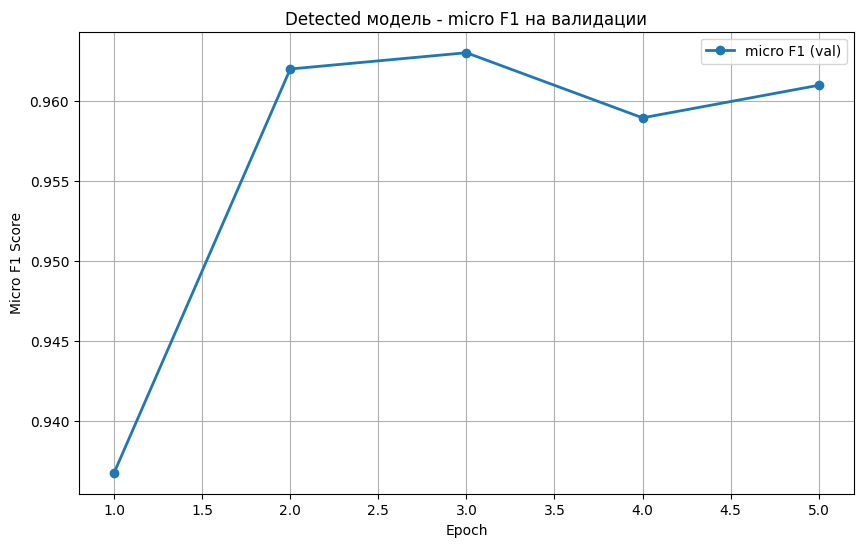

График для Split модели:


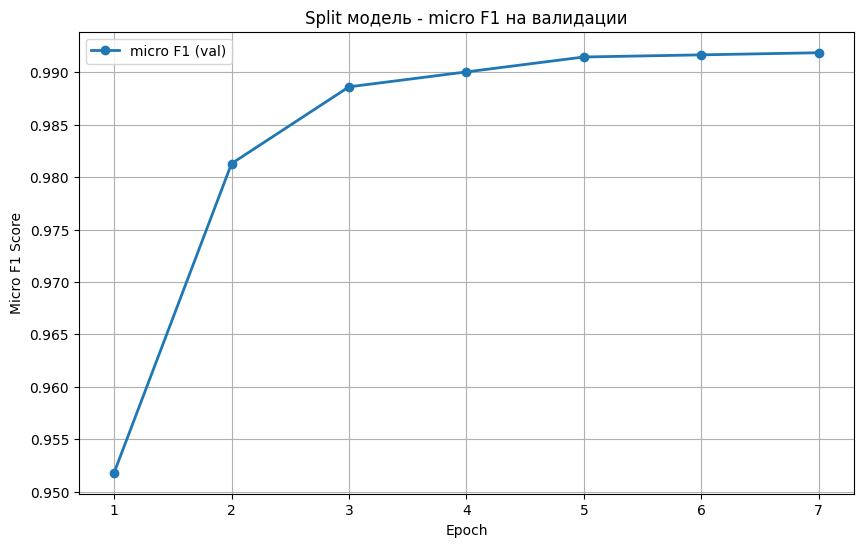

In [13]:
def plot_metrics(trainer, title):
    history = trainer.state.log_history
    epochs = []
    f1_scores = []
    
    for x in history:
        if 'eval_micro_f1' in x:
            epochs.append(x.get('epoch'))
            f1_scores.append(x.get('eval_micro_f1'))
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, f1_scores, marker='o', linewidth=2, label='micro F1 (val)')
    plt.xlabel('Epoch')
    plt.ylabel('Micro F1 Score')
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

# После окончания обучения обеих моделей:
print("График для Detected модели:")
plot_metrics(trainer_detected, "Detected модель - micro F1 на валидации")

print("График для Split модели:")
plot_metrics(trainer_split, "Split модель - micro F1 на валидации")

In [14]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available (ROCm для AMD):", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("Current device:", torch.cuda.current_device())
    print("GPU name:", torch.cuda.get_device_name(0))
    print("ROCm/HIP version info:")
    print(torch.version.hip)   # если None — значит не ROCm
else:
    print("GPU НЕ обнаружен! Обучение идёт на CPU.")

PyTorch version: 2.11.0+cu130
CUDA available (ROCm для AMD): False
Device count: 0
GPU НЕ обнаружен! Обучение идёт на CPU.
